In [1]:
# IPL Auction Price Predictor
# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


✅ Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.2.6


In [2]:
# Step 2: Load Dataset

stats = pd.read_csv('../data/raw/ipl_player_stats.csv')
auction = pd.read_csv('../data/raw/ipl_auction_data.csv')

print("✅ Data loaded successfully!")
print(f"\n📊 Player Stats Shape: {stats.shape}")
print(f"📊 Auction Data Shape: {auction.shape}")
print("\n--- First 5 rows of Stats ---")
stats.head()

✅ Data loaded successfully!

📊 Player Stats Shape: (312, 15)
📊 Auction Data Shape: (52, 7)

--- First 5 rows of Stats ---


,player_name,country,role,age,season,team,matches,runs,strike_rate,batting_avg,fifties,hundreds,wickets,economy_rate,bowling_avg
0,Virat Kohli,India,Batsman,30,2018,RR,14,313,149.3,42.7,2,0,0,5.0,0.0
1,Rohit Sharma,India,Batsman,31,2018,RCB,10,544,103.8,33.1,4,1,0,5.0,0.0
2,KL Rahul,India,Batsman,27,2018,RCB,13,389,137.1,38.2,3,1,0,5.0,0.0
3,Shubman Gill,India,Batsman,19,2018,RCB,11,328,186.1,41.9,3,0,0,5.0,0.0
4,Faf du Plessis,South Africa,Batsman,34,2018,RR,14,307,157.1,40.9,3,1,0,5.0,0.0


In [3]:
# Step 3: Exploratory Data Analysis

print("📊 Basic Statistics of Player Stats:")
print(stats.describe().round(2))

📊 Basic Statistics of Player Stats:
          age   season  matches    runs  strike_rate  batting_avg  fifties  \
count  312.00   312.00   312.00  312.00       312.00       312.00   312.00   
mean    29.00  2020.50    11.66  241.12       128.46        27.39     1.25   
std      4.99     1.71     2.29  160.17        26.48        12.49     1.34   
min     16.00  2018.00     8.00    0.00        58.90         5.00     0.00   
25%     25.00  2019.00    10.00   93.00       107.62        18.10     0.00   
50%     30.00  2020.50    12.00  233.00       129.35        27.25     1.00   
75%     33.00  2022.00    14.00  358.75       148.65        35.17     2.00   
max     40.00  2023.00    15.00  715.00       190.80        65.80     4.00   

       hundreds  wickets  economy_rate  bowling_avg  
count    312.00   312.00        312.00       312.00  
mean       0.21     7.55          7.12        16.35  
std        0.40     6.84          1.93        14.19  
min        0.00     0.00          5.00       

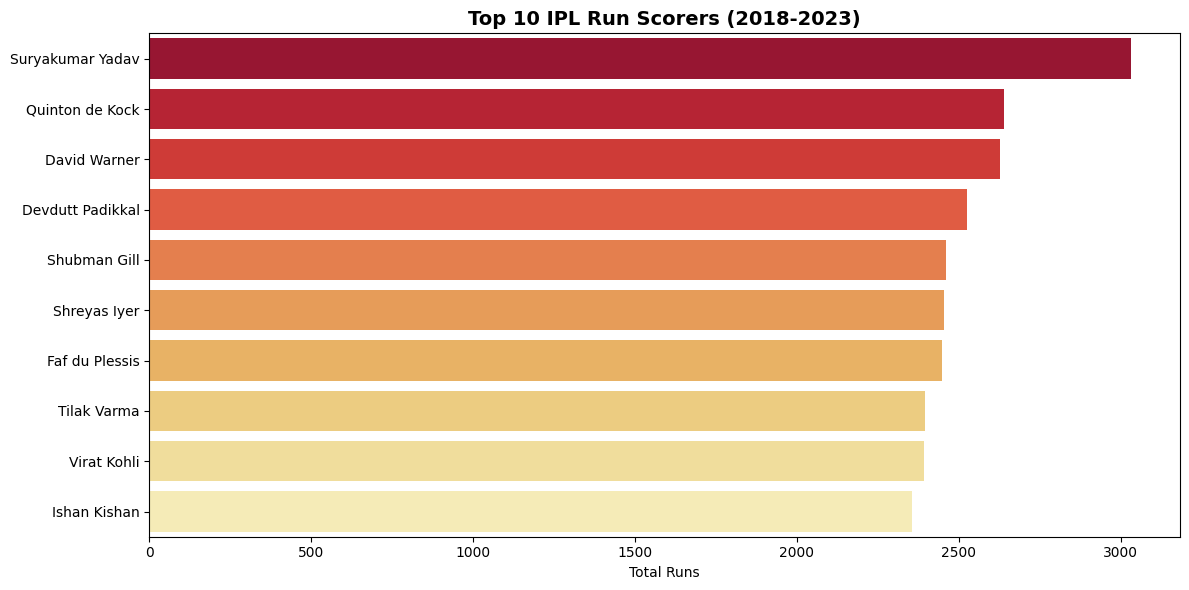

✅ Plot generated!


In [4]:
# Step 4: Top 10 Run Scorers Visualization

plt.figure(figsize=(12, 6))
run_agg = stats.groupby('player_name')['runs'].sum().nlargest(10).reset_index()
sns.barplot(data=run_agg, x='runs', y='player_name', palette='YlOrRd_r')
plt.title('Top 10 IPL Run Scorers (2018-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Total Runs')
plt.ylabel('')
plt.tight_layout()
plt.show()

print("✅ Plot generated!")

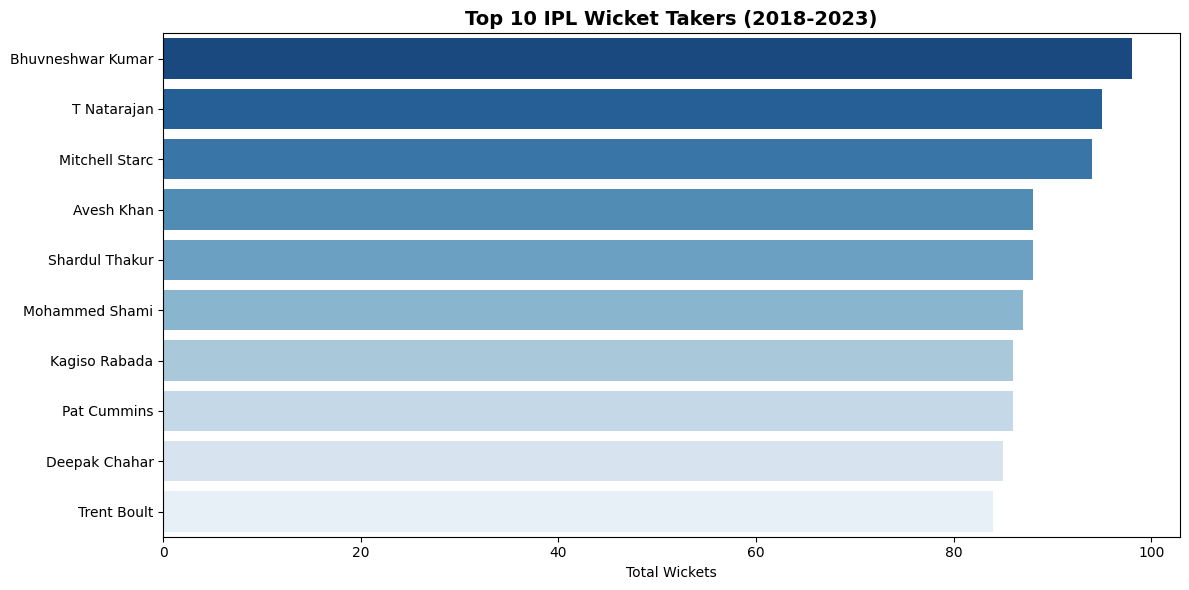

✅ Plot generated!


In [5]:
# Step 5: Top 10 Wicket Takers

plt.figure(figsize=(12, 6))
wkt_agg = stats[stats['wickets'] > 0].groupby('player_name')['wickets'].sum().nlargest(10).reset_index()
sns.barplot(data=wkt_agg, x='wickets', y='player_name', palette='Blues_r')
plt.title('Top 10 IPL Wicket Takers (2018-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Total Wickets')
plt.ylabel('')
plt.tight_layout()
plt.show()

print("✅ Plot generated!")

Task was destroyed but it is pending!
task: <Task pending name='Task-138' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at C:\Users\HP\Downloads\ipl_auction_predictor\ipl_env\lib\site-packages\ipykernel\utils.py:76> wait_for=<Task pending name='Task-139' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\HP\Downloads\ipl_auction_predictor\ipl_env\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\HP\Downloads\ipl_auction_predictor\ipl_env\lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-139' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\HP\Downloads\ipl_auction_predictor\ipl_env\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]>


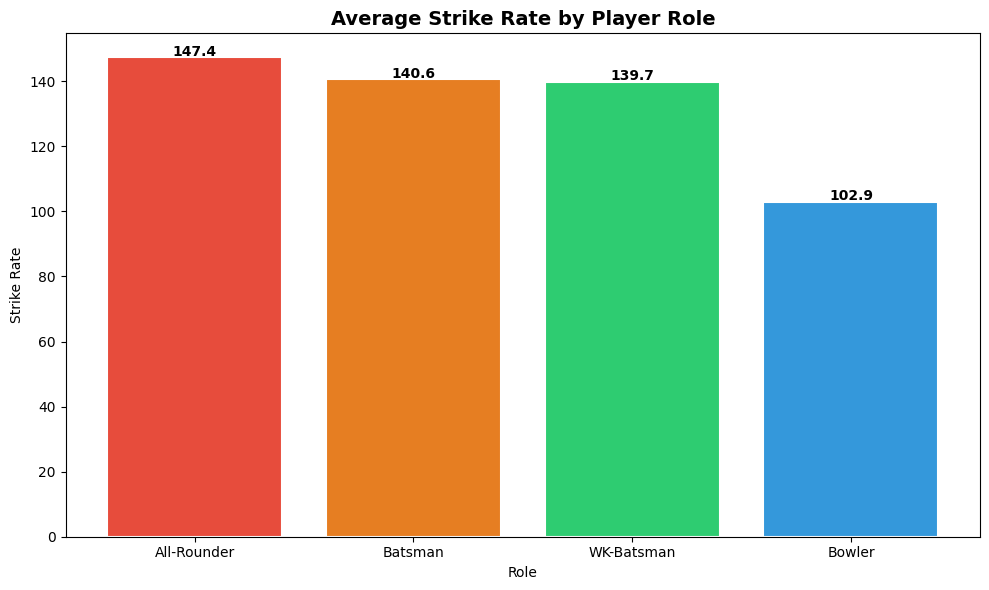

✅ Plot generated!


In [6]:
# Step 6: Strike Rate by Role Analysis

plt.figure(figsize=(10, 6))
sr_role = stats.groupby('role')['strike_rate'].mean().reset_index().sort_values('strike_rate', ascending=False)
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db']
plt.bar(sr_role['role'], sr_role['strike_rate'], color=colors, edgecolor='white', linewidth=1.5)
plt.title('Average Strike Rate by Player Role', fontsize=14, fontweight='bold')
plt.xlabel('Role')
plt.ylabel('Strike Rate')
for i, v in enumerate(sr_role['strike_rate']):
    plt.text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Plot generated!")

In [8]:
# Step 7: Feature Engineering - Custom Impact Score

def impact_score(row):
    if row['role'] in ['Batsman', 'WK-Batsman']:
        score = (row['runs'] / 10) + (row['fifties'] * 5) + (row['hundreds'] * 15)
    elif row['role'] == 'Bowler':
        eco_bonus = max(0, (10 - row['economy_rate']) * 8)
        score = (row['wickets'] * 8) + eco_bonus
    else:
        score = (row['runs'] / 15) + (row['fifties'] * 4) + (row['wickets'] * 6)
    return round(score, 2)

stats['impact_score'] = stats.apply(impact_score, axis=1)

print("✅ Impact Score calculated!")
print("\n📌 Top 10 Players by Impact Score:")
print(stats.groupby('player_name')['impact_score'].mean().nlargest(10).reset_index().to_string(index=False))

✅ Impact Score calculated!

📌 Top 10 Players by Impact Score:
      player_name  impact_score
      T Natarajan    145.133333
Bhuvneshwar Kumar    143.666667
   Mitchell Starc    139.786667
    Kagiso Rabada    138.733333
   Shardul Thakur    135.080000
    Deepak Chahar    134.666667
 Yuzvendra Chahal    133.120000
   Mohammed Shami    131.946667
       Avesh Khan    130.920000
   Arshdeep Singh    124.640000


In [9]:
# Step 8: Load Processed Data & Train ML Model

features = pd.read_csv('../data/processed/ipl_features.csv')

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

le_role = LabelEncoder()
le_country = LabelEncoder()
features['role_enc'] = le_role.fit_transform(features['role'].fillna('Batsman'))
features['country_enc'] = le_country.fit_transform(features['country'].fillna('India'))

FEATURES = ['age', 'role_enc', 'country_enc', 'base_price_lakhs', 'is_star',
            'total_runs', 'avg_sr', 'avg_bat_avg', 'total_50s', 'total_100s',
            'total_wkts', 'avg_eco', 'form_runs', 'form_wickets',
            'impact_score_norm', 'seasons_played']

X = features[FEATURES].fillna(0)
y = features['sold_price_cr']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("✅ Model Trained Successfully!")
print(f"\n🎯 R² Score  : {r2_score(y_test, y_pred):.4f}")
print(f"📉 RMSE      : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} Cr")
print(f"📉 MAE       : {mean_absolute_error(y_test, y_pred):.2f} Cr")

✅ Model Trained Successfully!

🎯 R² Score  : 0.8671
📉 RMSE      : 42.40 Cr
📉 MAE       : 35.26 Cr


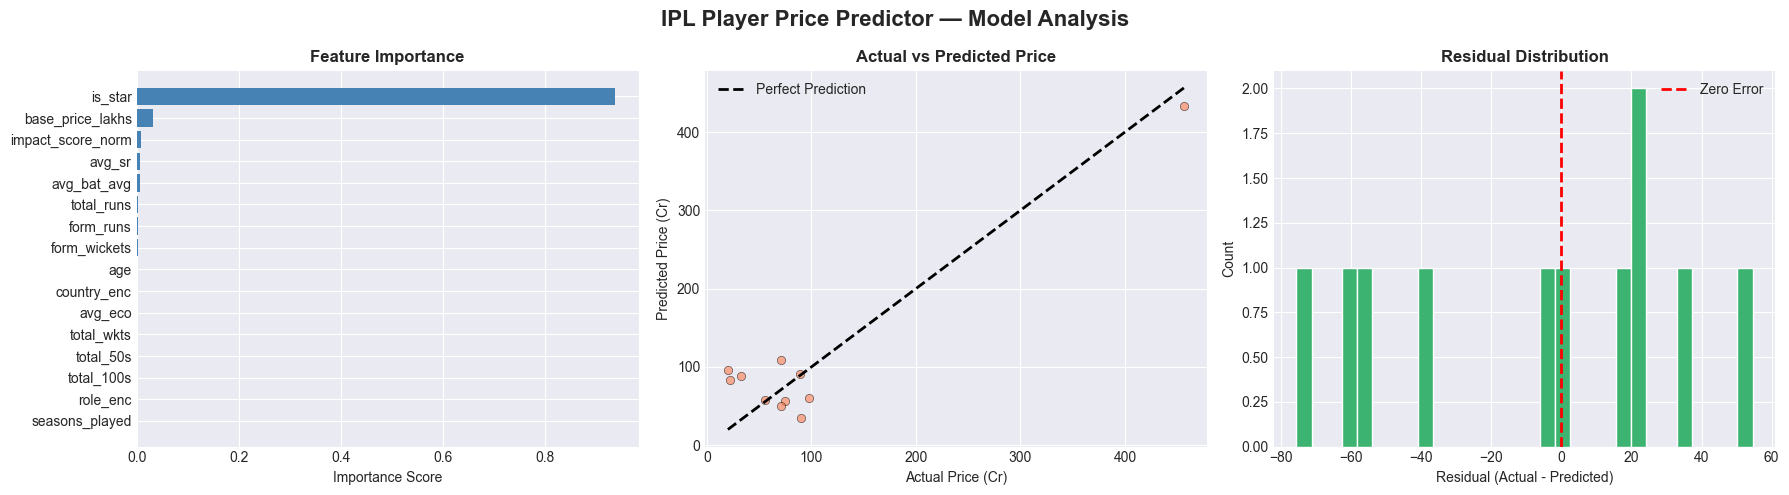

✅ Plots saved as model_analysis.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Plot style ──────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('IPL Player Price Predictor — Model Analysis', fontsize=16, fontweight='bold')

# ── 1. Feature Importance ───────────────────────────────
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [FEATURES[i] for i in indices]
sorted_importances = importances[indices]

axes[0].barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue')
axes[0].set_title('Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# ── 2. Actual vs Predicted ──────────────────────────────
axes[1].scatter(y_test, y_pred, alpha=0.6, color='coral', edgecolors='k', linewidths=0.5)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')
axes[1].set_title('Actual vs Predicted Price', fontweight='bold')
axes[1].set_xlabel('Actual Price (Cr)')
axes[1].set_ylabel('Predicted Price (Cr)')
axes[1].legend()

# ── 3. Residual Distribution ────────────────────────────
residuals = y_test - y_pred
axes[2].hist(residuals, bins=30, color='mediumseagreen', edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[2].set_title('Residual Distribution', fontweight='bold')
axes[2].set_xlabel('Residual (Actual - Predicted)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plots saved as model_analysis.png")

In [11]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
import warnings
warnings.filterwarnings('ignore')

# ── Parameter Grid ──────────────────────────────────────
param_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 0.9, 1.0]
}

# ── RandomizedSearchCV ──────────────────────────────────
search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("⏳ Tuning in progress... (1-2 min lagenge)")
search.fit(X_train, y_train)

# ── Best Model ──────────────────────────────────────────
best_model = search.best_estimator_
y_pred_best = best_model.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("\n✅ Tuning Complete!")
print(f"🏆 Best Params  : {search.best_params_}")
print(f"\n📊 OLD Model:")
print(f"   R² Score : {r2_score(y_test, y_pred):.4f}")
print(f"   RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} Cr")
print(f"\n🚀 NEW Tuned Model:")
print(f"   R² Score : {r2_score(y_test, y_pred_best):.4f}")
print(f"   RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f} Cr")

# ── Cross Validation ────────────────────────────────────
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')
print(f"\n📈 Cross-Validation R² Scores: {cv_scores.round(3)}")
print(f"   Mean CV R² : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

⏳ Tuning in progress... (1-2 min lagenge)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Tuning Complete!
🏆 Best Params  : {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 3, 'learning_rate': 0.01}

📊 OLD Model:
   R² Score : 0.8671
   RMSE     : 42.40 Cr

🚀 NEW Tuned Model:
   R² Score : 0.8852
   RMSE     : 39.41 Cr

📈 Cross-Validation R² Scores: [0.96  0.933 0.752 0.967 0.967]
   Mean CV R² : 0.9158 ± 0.0827


In [12]:
import os
print(os.getcwd())

C:\Users\HP\Downloads\ipl_auction_predictor\ipl_project\notebooks


In [13]:
import pickle
import os

# notebooks ke bahar ipl_project folder mein save karenge
save_path = r'C:\Users\HP\Downloads\ipl_auction_predictor\ipl_project'

with open(os.path.join(save_path, 'model.pkl'), 'wb') as f:
    pickle.dump(best_model, f)

with open(os.path.join(save_path, 'encoders.pkl'), 'wb') as f:
    pickle.dump({'le_role': le_role, 'le_country': le_country}, f)

print("✅ model.pkl aur encoders.pkl save ho gaye!")
print(f"📁 Location: {save_path}")

✅ model.pkl aur encoders.pkl save ho gaye!
📁 Location: C:\Users\HP\Downloads\ipl_auction_predictor\ipl_project
